### 𝗟𝗶𝘃𝗲 - 𝗙𝗲𝗮𝘁𝘂𝗿𝗲 𝗘𝗻𝗴𝗶𝗻𝗲𝗲𝗿𝗶𝗻𝗴 - 𝗔𝗹𝗹 𝗧𝗲𝗰𝗵𝗻𝗶𝗾𝘂𝗲 𝗧𝗼 𝗛𝗮𝗻𝗱𝗹𝗲 𝗠𝗶𝘀𝘀𝗶𝗻𝗴 𝗩𝗮𝗹𝘂𝗲𝘀-𝗗𝗮𝘆 𝟭

Lifecycle of a Data Science Projects

1. Data Collection Statergy---from company side,3rd party Api's, Surveys
2. Feature Engineering---Handling Missing values

Why are their Missing values??Survey--Depression Survey

1. They hesitate to put down the information
2. Survey informations are not that valid
3. Men--salary
4. Women---age
5. People may have died----NAN

Data Science Projects---Dataset should be collected from multiple sources


## What are the different types of Missing Data?

1. Missing Completely at Random, MCAR:-->
A variable is missing completely at random (MCAR) if the probability of being missing is the same for all the observations. When data is MCAR, there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. In other words, those missing data points are a random subset of the data. There is nothing systematic going on that makes some data more likely to be missing than other.

In [2]:
import pandas as pd 

In [3]:
df=pd.read_csv('titanic.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Eg of MCAR is Embarked because there is no realationship between them to any another Values.

In [6]:
df[df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


2. Missing Data Not At Random(MNAR):--> Systematic missing values

there is absolutely no relationship between the data missing and any other values, observed or missing, within the dataset. 

In [7]:
import numpy as np 
df['Cabin_null']=np.where(df['Cabin'].isnull(),1,0)

## Find the percentage of null values 
df['Cabin_null'].mean()

np.float64(0.7710437710437711)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Cabin_null'],
      dtype='object')

In [9]:
df.groupby(['Survived'])['Cabin_null'].mean()

Survived
0    0.876138
1    0.602339
Name: Cabin_null, dtype: float64

3. Missing At Random(MAR)



1. Men---hide therir salary
2. Women---hide their age

###  All the technique of handling missing values

1. Mean/Meadian/Mode replacement
2. Rondom Sample Imputation
3. Capturing NAN values with a new feature
4. End of Distribution imputation
5. Arbitrary imputation
6. Frequent categories imputation 

### 1. Mean/Median/Mode imputation
When should We apply?
Mean/median imputation has the assumpation that the data are missing completely at random(MCAR).We solve this by replacing the NaN with most frequent occurance of the variables


In [10]:
df=pd.read_csv('titanic.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
## Let's go and see the percentage of missing values 
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [12]:
median=df['Age'].median()
median

np.float64(28.0)

In [13]:
def impute_nan(df, variable, median):
    df[variable+"_median"]=df[variable].fillna(median)

In [14]:
impute_nan(df,'Age',median)
df.head()

,Survived,Age,Fare,Age_median
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [15]:
print(df['Age'].std())
print(df['Age_median'].std())

14.526497332334042
13.019696550973201


In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

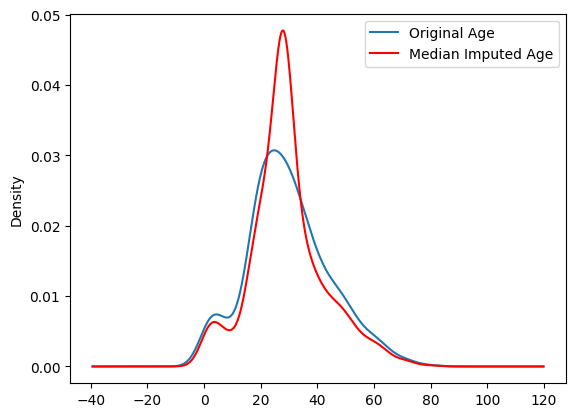

In [26]:

fig = plt.figure()
ax = fig.add_subplot(111)

df['Age'].plot(kind='kde', ax=ax, label='Original Age')
df['Age_median'].plot(kind='kde', ax=ax, color='red', label='Median Imputed Age')

ax.legend(loc='best')

### Advantage And Disadvantages of mean/median Imputation

### Advantages
1. Easy to implement(Robust to outliers)
2. Faster way to obtain the complete dataset

### Disadvantages
1. Change or Distortion in the original variance
2. Impacts Correlation